In [1]:
#Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE


from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

In [2]:
df = pd.read_csv("Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

print("Initial shape:", df.shape)
print(df.head())

# Clean column names by removing leading/trailing spaces
df.columns = df.columns.str.strip()

Initial shape: (225745, 79)
    Destination Port   Flow Duration   Total Fwd Packets  \
0              54865               3                   2   
1              55054             109                   1   
2              55055              52                   1   
3              46236              34                   1   
4              54863               3                   2   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        0                           12   
1                        1                            6   
2                        1                            6   
3                        1                            6   
4                        0                           12   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                             0                       6   
1                             6                       6   
2                             6                       6   
3                   

In [3]:
columns_to_drop = ["Flow ID", "Source IP", "Destination IP", "Timestamp"]

# Drop only those columns which actually exist in the dataset
df.drop([col for col in columns_to_drop if col in df.columns], 
        axis=1, 
        inplace=True)

print("Dropped columns:", columns_to_drop)

Dropped columns: ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp']


In [4]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
print("After cleaning:", df.shape)

After cleaning: (225711, 79)


In [5]:
encoder = LabelEncoder()
df["Label"] = encoder.fit_transform(df["Label"])
print("Classes:", encoder.classes_)

Classes: ['BENIGN' 'DDoS']


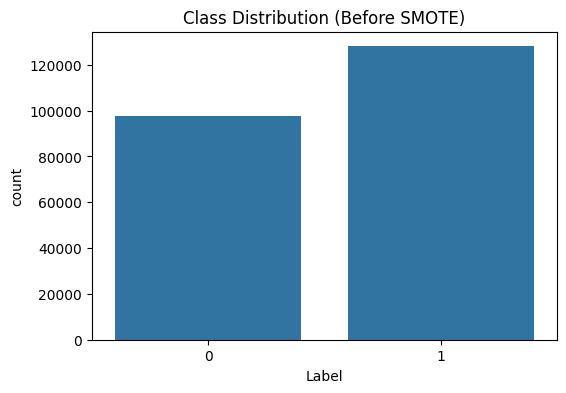

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["Label"])

plt.title("Class Distribution (Before SMOTE)")
plt.show()

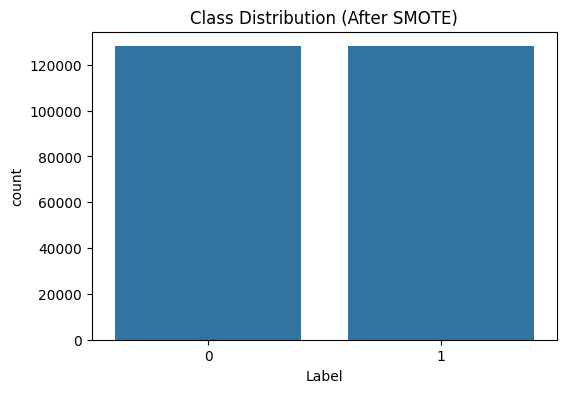

In [7]:
X = df.drop("Label", axis=1)
y = df["Label"]

# Handle class imbalance
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

plt.figure(figsize=(6,4))
sns.countplot(x=y_res)
plt.title("Class Distribution (After SMOTE)")
plt.show()

In [9]:
#Feature Scaling

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_res)


#Split train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_res, test_size=0.2, random_state=42, stratify=y_res
)

In [10]:
# Dimensionality reduction

pca = PCA(n_components=20, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [11]:
#import require model
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, n_jobs=-1),
    "SGDClassifier": SGDClassifier(loss='log_loss', max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(max_depth=15),
    "Random Forest": RandomForestClassifier(n_estimators=300, n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(
        n_estimators=400, max_depth=8, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, eval_metric='logloss'
    )
}

# Train & Evaluate Models
for name, model in models.items():
    print(f"\nTraining: {name}")
    model.fit(X_train_pca, y_train)

    preds = model.predict(X_test_pca)
    acc = accuracy_score(y_test, preds)

    print(f"Accuracy: {acc*100:.2f}%")
    print(classification_report(y_test, preds))


Training: Logistic Regression
Accuracy: 99.23%
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     25605
           1       0.99      1.00      0.99     25605

    accuracy                           0.99     51210
   macro avg       0.99      0.99      0.99     51210
weighted avg       0.99      0.99      0.99     51210


Training: SGDClassifier
Accuracy: 98.75%
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     25605
           1       0.98      1.00      0.99     25605

    accuracy                           0.99     51210
   macro avg       0.99      0.99      0.99     51210
weighted avg       0.99      0.99      0.99     51210


Training: Decision Tree
Accuracy: 99.96%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25605
           1       1.00      1.00      1.00     25605

    accuracy                           1.00     51

In [12]:
accuracy_dict = {}

for name, model in models.items():
    model.fit(X_train_pca, y_train)
    preds = model.predict(X_test_pca)
    acc = accuracy_score(y_test, preds)
    accuracy_dict[name] = acc * 100

# Convert to DataFrame
acc_df = pd.DataFrame.from_dict(
    accuracy_dict, orient='index', columns=['Accuracy (%)']
)

# Sort in descending order
acc_df = acc_df.sort_values(by='Accuracy (%)', ascending=False)

print("\n Model Accuracy Comparison")
print(acc_df)


 Model Accuracy Comparison
                     Accuracy (%)
XGBoost                 99.980473
Random Forest           99.978520
Decision Tree           99.960945
Logistic Regression     99.228666
SGDClassifier           98.898653
Naive Bayes             83.780512
